08:31:55 - cmdstanpy - INFO - Chain [1] start processing
08:31:55 - cmdstanpy - INFO - Chain [1] done processing


             ds        yhat  yhat_lower  yhat_upper
1067 2026-12-03  197.980671  104.304448  286.349517
1068 2026-12-04  196.102603  107.976032  292.271068
1069 2026-12-05  208.673704  115.210559  303.579694
1070 2026-12-06  207.014486  123.361872  303.020363
1071 2026-12-07  218.492722  125.018362  311.720416


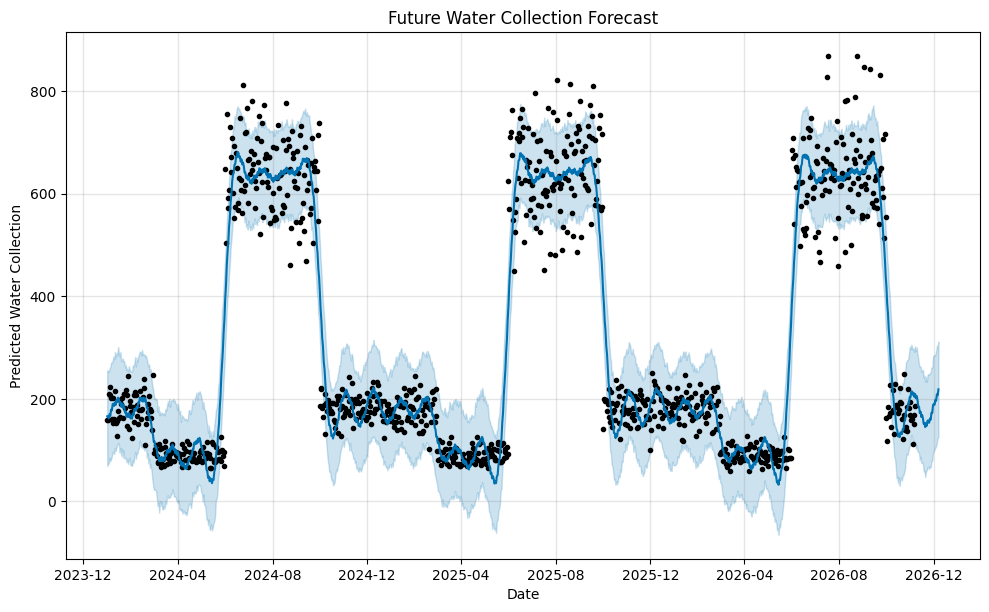

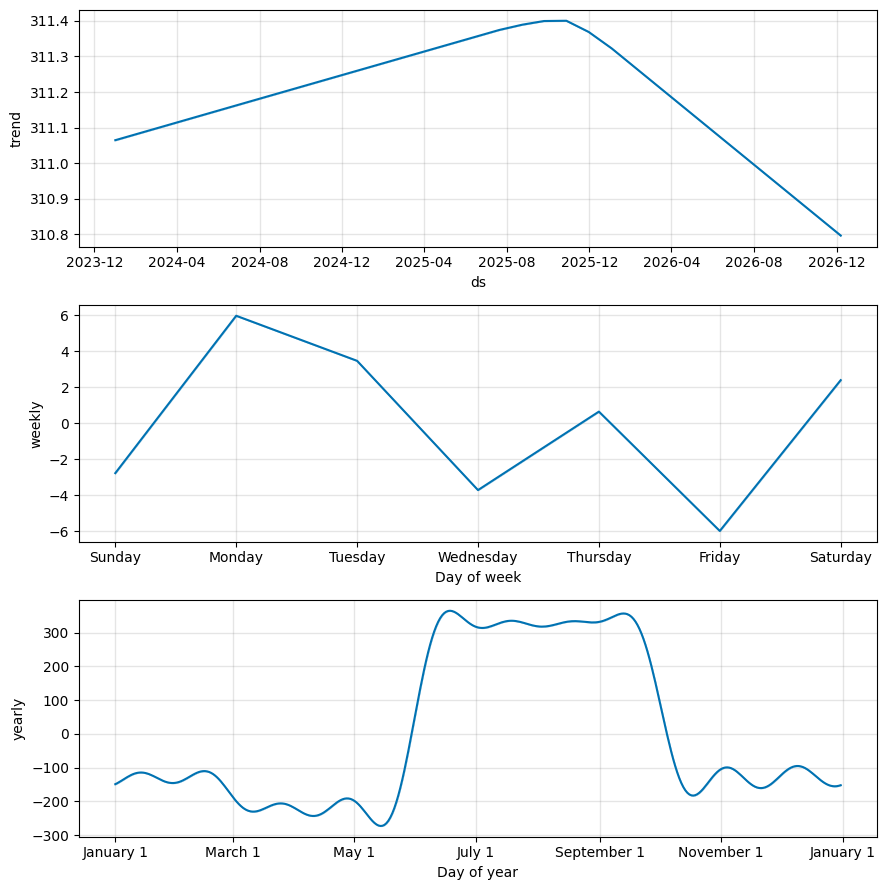


Forecast Results Saved!


In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from prophet import Prophet

# -----------------------------
# LOAD DATA
# -----------------------------

df = pd.read_csv(
    "../../data/smart_water_dataset.csv"
)

# -----------------------------
# CONVERT DATETIME
# -----------------------------

df["datetime"] = pd.to_datetime(
    df["datetime"]
)

# -----------------------------
# GROUP DAILY DATA
# -----------------------------

daily_data = df.groupby(
    df["datetime"].dt.date
)["water_collected"].mean().reset_index()

# -----------------------------
# RENAME COLUMNS FOR PROPHET
# -----------------------------

daily_data.columns = ["ds", "y"]

# -----------------------------
# CREATE MODEL
# -----------------------------

model = Prophet()

# -----------------------------
# TRAIN MODEL
# -----------------------------

model.fit(daily_data)

# -----------------------------
# FUTURE DATES
# -----------------------------

future = model.make_future_dataframe(
    periods=30
)

# -----------------------------
# FORECAST
# -----------------------------

forecast = model.predict(future)

# -----------------------------
# SHOW RESULTS
# -----------------------------

print(
    forecast[
        ["ds", "yhat", "yhat_lower", "yhat_upper"]
    ].tail()
)

# -----------------------------
# PLOT FORECAST
# -----------------------------

fig1 = model.plot(forecast)

plt.title(
    "Future Water Collection Forecast"
)

plt.xlabel("Date")

plt.ylabel("Predicted Water Collection")

plt.show()

# -----------------------------
# PLOT COMPONENTS
# -----------------------------

fig2 = model.plot_components(
    forecast
)

plt.show()

# -----------------------------
# SAVE FORECAST
# -----------------------------

forecast.to_csv(
    "../../data/forecast_results.csv",
    index=False
)

print(
    "\nForecast Results Saved!"
)